<a href="https://colab.research.google.com/github/ltd03112007-lab/palmistry/blob/main/Palmistry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 15.9 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
pip install Pillow

In [ ]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.5 MB/s eta 0:00:00


In [ ]:
!pip install networkx==2.8.8
import os
os.kill(os.getpid(), 9)  # restart runtime

Khởi tạo MediaPipe Hand Landmarker...
Đang xử lý ảnh: /content/taykhang.jpg
Crop 4 vùng thành công!

 Đang tải 4 mô hình CNN...
  📦 Loading /content/sinhdao30.h5 ...


  📦 Loading /content/tamdao30.h5 ...
  📦 Loading /content/tridao30.h5 ...


  📦 Loading /content/sunghiep30.h5 ...
 Tải xong 4 mô hình CNN!

 Đang dự đoán...

 XÁC SUẤT ĐẦU RA TỪ CNN:
  sinh_dao    : Ngắn=0.465 | TB=0.203 | Dài=0.332
  tam_dao     : Ngắn=0.328 | TB=0.230 | Dài=0.442
  tri_dao     : Ngắn=0.420 | TB=0.267 | Dài=0.313
  su_nghiep   : Ngắn=0.238 | TB=0.330 | Dài=0.432

⚙️  CRISP VALUES → FUZZY:
  sinh_dao    : 0.4339
  tam_dao     : 0.5569
  tri_dao     : 0.4461
  su_nghiep   : 0.5968

 Đang chạy Fuzzy Logic...


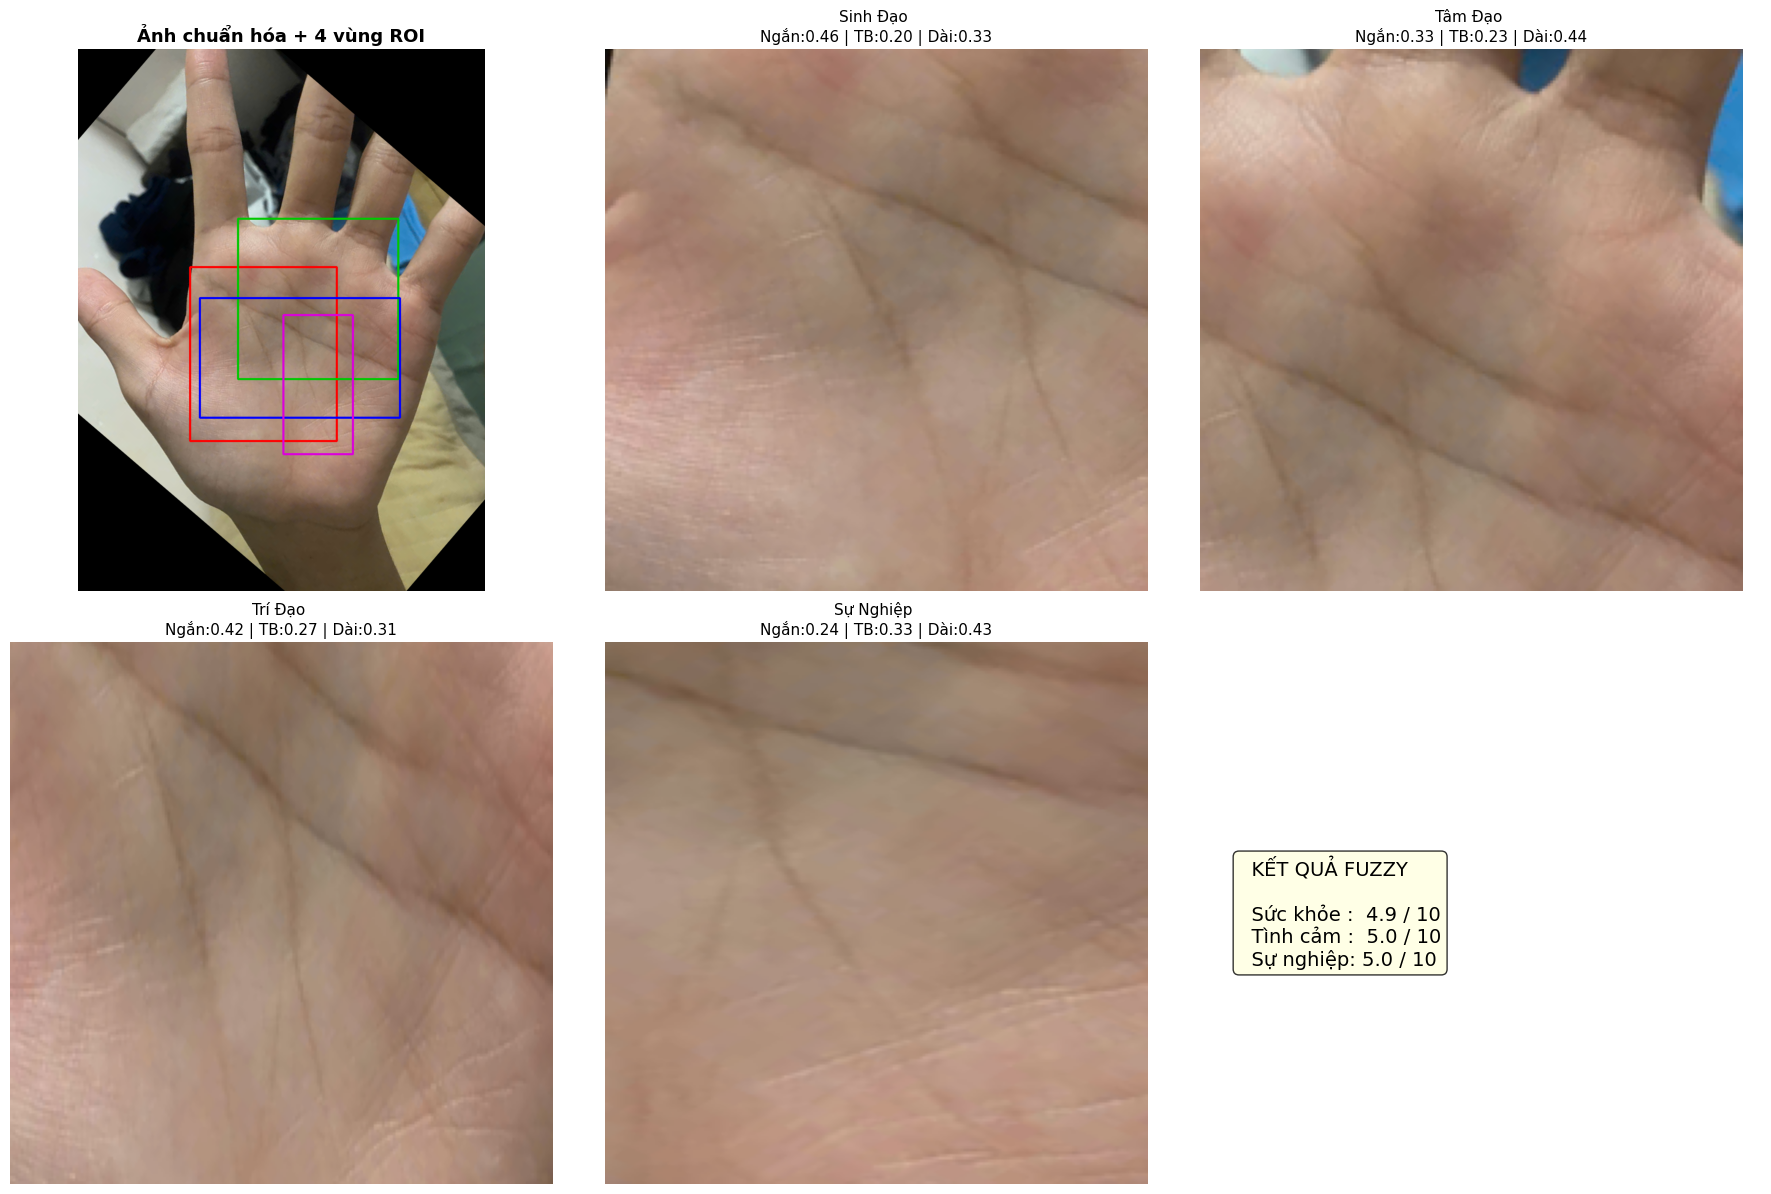


  BẢN THUẬT XEM TƯỚNG TAY ĐIỆN TỬ
  Sinh Đạo (4.9/10): Thể trạng của bạn ở mức trung bình. Hãy chú ý giữ gìn sức khỏe, ăn uống điều độ.

 Điểm khuynh hướng tâm lý (5.0/10):
   >> Bạn sở hữu một sự cân bằng tốt. Dù có tư duy thực tế, logic, bạn vẫn giữ được sự ấm áp trong các mối quan hệ.

 Định hướng Công Danh (5.0/10):
   >> Sự nghiệp của bạn ít biến động, ổn định. Một cuộc sống an toàn và bình yên đang chờ đón bạn.


In [ ]:
import os
import urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def init_mediapipe():
    model_path = 'hand_landmarker.task'
    if not os.path.exists(model_path):
        print("📥 Đang tải mô hình MediaPipe...")
        url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
        urllib.request.urlretrieve(url, model_path)
        print("Tải xong!")
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
    return vision.HandLandmarker.create_from_options(options)

def safe_rect_crop(cx, cy, w_size, h_size, src_img):
    hb_w, hb_h = w_size // 2, h_size // 2
    x1 = max(0, cx - hb_w)
    y1 = max(0, cy - hb_h)
    x2 = min(src_img.shape[1], cx + hb_w)
    y2 = min(src_img.shape[0], cy + hb_h)
    crop = src_img[y1:y2, x1:x2]
    if crop.size != 0:
        return cv2.resize(crop, (200, 200)), (x1, y1, x2, y2)
    return None, None

def process_image(image_path, detector):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Không tìm thấy ảnh: '{image_path}'")

    h, w, _ = img.shape
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = detector.detect(mp_image)
    if not result.hand_landmarks:
        raise ValueError("❌ Không phát hiện bàn tay trong ảnh!")

    lm = result.hand_landmarks[0]
    pt0 = np.array([int(lm[0].x * w), int(lm[0].y * h)])
    pt9 = np.array([int(lm[9].x * w), int(lm[9].y * h)])
    angle_rad = np.arctan2(-(pt9[1] - pt0[1]), pt9[0] - pt0[0])
    rotate_angle = 90 - np.degrees(angle_rad)

    M = cv2.getRotationMatrix2D((w // 2, h // 2), rotate_angle, 1.0)
    img_rotated = cv2.warpAffine(img_rgb, M, (w, h))

    mp_rotated = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rotated)
    result2 = detector.detect(mp_rotated)
    if not result2.hand_landmarks:
        raise ValueError("❌ Không phát hiện bàn tay sau khi xoay!")

    lm2 = np.array([[int(p.x * w), int(p.y * h)] for p in result2.hand_landmarks[0]])
    palm_size = int(np.linalg.norm(lm2[9] - lm2[0]))
    box_size   = int(palm_size * 0.6)

    # 1. Sinh Đạo (đường Sinh mệnh) — lòng bàn tay, ôm đường cung
    cx1 = int(0.35*lm2[0][0] + 0.45*lm2[5][0] + 0.20*lm2[9][0])
    cy1 = int(0.40*lm2[0][1] + 0.40*lm2[5][1] + 0.20*lm2[9][1])
    roi_sinh_dao, box1 = safe_rect_crop(cx1, cy1, int(palm_size*0.55), int(palm_size*0.65), img_rotated)

    # 2. Tâm Đạo (đường Cảm xúc) — sát khấc ngón tay
    cx2 = int((lm2[5][0] + lm2[17][0]) / 2)
    cy2 = int(0.20*lm2[0][1] + 0.80*lm2[9][1])
    roi_tam_dao, box2 = safe_rect_crop(cx2, cy2, box_size, box_size, img_rotated)

    # 3. Trí Đạo (đường Trí tuệ) — HCN ngang dẹt
    cx3 = int(0.60*lm2[5][0] + 0.40*lm2[17][0])
    cy3 = int(0.42*lm2[0][1] + 0.58*lm2[9][1])
    roi_tri_dao, box3 = safe_rect_crop(cx3, cy3, int(palm_size*0.75), int(palm_size*0.45), img_rotated)

    # 4. Sự Nghiệp (đường Vận mệnh) — cô lập đường dọc giữa lòng bàn tay
    cx4 = int(0.65*lm2[9][0] + 0.35*lm2[13][0])
    cy4 = int(0.52*lm2[0][1] + 0.48*lm2[9][1])
    roi_su_nghiep, box4 = safe_rect_crop(cx4, cy4, int(palm_size*0.26), int(palm_size*0.52), img_rotated)

    crops = {
        'sinh_dao':  roi_sinh_dao,
        'tam_dao':   roi_tam_dao,
        'tri_dao':   roi_tri_dao,
        'su_nghiep': roi_su_nghiep,
    }
    for name, crop in crops.items():
        if crop is None:
            raise ValueError(f"❌ Crop vùng '{name}' thất bại — vùng nằm ngoài ảnh!")

    img_illus = img_rotated.copy()
    colors = [(255,0,0), (0,200,0), (0,0,255), (220,0,220)]
    for box, color in zip([box1, box2, box3, box4], colors):
        if box:
            cv2.rectangle(img_illus, (box[0], box[1]), (box[2], box[3]), color, 3)

    return crops, img_illus

def preprocess_for_cnn(crop_rgb):
    """
    Nhận numpy array (200, 200, 3) RGB uint8.
    Trả về tensor (1, 200, 200, 3) float32 đã normalize.
    """
    img_float = crop_rgb.astype(np.float32) / 255.0
    return np.expand_dims(img_float, axis=0)

def load_models(paths: dict):
    """
    paths = {
        'sinh_dao':  '/content/sinhdao30.h5',
        'tam_dao':   '/content/tamdao30.h5',
        'tri_dao':   '/content/tridao30.h5',
        'su_nghiep': '/content/sunghiep30.h5',
    }
    """
    models = {}
    for key, path in paths.items():
        print(f"  📦 Loading {path} ...")
        models[key] = tf.keras.models.load_model(path)
    print(" Tải xong 4 mô hình CNN!")
    return models

def predict_all(models: dict, crops: dict):
    CLASSES = ['ngan', 'trung_binh', 'dai']
    probs = {}
    for key in ['sinh_dao', 'tam_dao', 'tri_dao', 'su_nghiep']:
        x = preprocess_for_cnn(crops[key])
        pred = models[key].predict(x, verbose=0)[0]   # shape (3,)
        probs[key] = {CLASSES[i]: float(pred[i]) for i in range(3)}
    return probs

def calc_crisp_weight(prob_dict: dict) -> float:
    return (prob_dict['ngan'] * 0.0
          + prob_dict['trung_binh'] * 0.5
          + prob_dict['dai'] * 1.0)

def build_fuzzy_system():
    sinh_dao  = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'sinh_dao')
    tam_dao   = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'tam_dao')
    tri_dao   = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'tri_dao')
    su_nghiep = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'su_nghiep')

    suc_khoe  = ctrl.Consequent(np.arange(0, 11, 1), 'suc_khoe')
    tinh_cam  = ctrl.Consequent(np.arange(0, 11, 1), 'tinh_cam')
    cong_danh = ctrl.Consequent(np.arange(0, 11, 1), 'cong_danh')

    for var in [sinh_dao, tam_dao, tri_dao, su_nghiep]:
        var.automf(names=['ngan', 'trung_binh', 'dai'])

    suc_khoe.automf(names=['kem', 'binh_thuong', 'tot'])
    tinh_cam.automf(names=['ly_tri', 'can_bang', 'cam_tinh'])
    cong_danh.automf(names=['bien_dong', 'on_dinh', 'thanh_cong'])

    rules = [
        # "Đường sinh đạo ngắn thì sức khỏe yếu, dễ mệt mỏi"
        ctrl.Rule(sinh_dao['ngan'], suc_khoe['kem']),
        # "Dài thì sức khỏe tốt, năng lượng dồi dào"
        ctrl.Rule(sinh_dao['dai'], suc_khoe['tot']),
        # Bổ trợ: Sinh đạo trung bình thì sức khỏe bình thường
        ctrl.Rule(sinh_dao['trung_binh'], suc_khoe['binh_thuong']),
        # Luật kết hợp: Năng lượng dồi dào + Sự nghiệp dài (Chịu áp lực tốt)
        ctrl.Rule(sinh_dao['dai'] & su_nghiep['dai'], suc_khoe['tot']),

        # "Đường tâm đạo ngắn thì ít quan tâm tình cảm, tập trung vào bản thân"
        ctrl.Rule(tam_dao['ngan'], tinh_cam['ly_tri']),
        # "Dài thì tình cảm mạnh mẽ, chân thành"
        ctrl.Rule(tam_dao['dai'], tinh_cam['cam_tinh']),
        # "Trí đạo ngắn thì tư duy thực tế" (Góp phần làm tăng tính lý trí, bớt bay bổng)
        ctrl.Rule(tri_dao['ngan'] & tam_dao['trung_binh'], tinh_cam['ly_tri']),
        # "Trí đạo dài thì lý trí, logic" + Tâm đạo ngắn -> Cực kỳ lạnh lùng, cá nhân
        ctrl.Rule(tri_dao['dai'] & tam_dao['ngan'], tinh_cam['ly_tri']),
        # Trí đạo dài + Tâm đạo dài -> Con người cân bằng giữa tình cảm mạnh mẽ và logic
        ctrl.Rule(tri_dao['dai'] & tam_dao['dai'], tinh_cam['can_bang']),
        # Tâm đạo trung bình
        ctrl.Rule(tam_dao['trung_binh'], tinh_cam['can_bang']),

        # "Sự nghiệp ngắn thì gặp nhiều thay đổi trong sự nghiệp"
        ctrl.Rule(su_nghiep['ngan'], cong_danh['bien_dong']),
        # "Dài thì sự nghiệp ổn định, ít biến động"
        ctrl.Rule(su_nghiep['dai'], cong_danh['on_dinh']),
        # "Trí đạo dài thì quyết đoán, logic" + Sự nghiệp dài -> Thành công lớn
        ctrl.Rule(su_nghiep['dai'] & tri_dao['dai'], cong_danh['thanh_cong']),
        # "Trí đạo ngắn thì thực tế, thiếu kiên nhẫn" + Sự nghiệp ngắn -> Cực kỳ biến động
        ctrl.Rule(su_nghiep['ngan'] & tri_dao['ngan'], cong_danh['bien_dong']),
        # Bổ trợ trung bình
        ctrl.Rule(su_nghiep['trung_binh'], cong_danh['on_dinh']),
    ]

    sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
    return sim

def interpret_results(sk, tc, cd):
    print("\n" + "="*60)
    print("  BẢN THUẬT XEM TƯỚNG TAY ĐIỆN TỬ")
    print("="*60)

    # --- BÌNH GIẢI SỨC KHỎE ---
    if sk >= 6.5:
        print(f"  Sinh Đạo ({sk:.1f}/10): Năng lượng của bạn rất dồi dào, sức khỏe tốt. Bạn có sinh lực bền bỉ để theo đuổi các mục tiêu dài hạn.")
    elif sk >= 3.5:
        print(f"  Sinh Đạo ({sk:.1f}/10): Thể trạng của bạn ở mức trung bình. Hãy chú ý giữ gìn sức khỏe, ăn uống điều độ.")
    else:
        print(f"  Sinh Đạo ({sk:.1f}/10): Sức khỏe của bạn có vẻ khá yếu, dễ bị mệt mỏi. Bạn nên dành nhiều thời gian hơn để nghỉ ngơi.")

    # --- BÌNH GIẢI TRÍ ĐẠO (TƯ DUY) & TÂM ĐẠO (TÌNH CẢM) ---
    print(f"\n Điểm khuynh hướng tâm lý ({tc:.1f}/10):")
    if tc >= 6.5:
        print("   >> Bạn là người có tình cảm rất mạnh mẽ và chân thành. Trái tim thường dẫn lối cho những quyết định của bạn.")
    elif tc >= 3.5:
        print("   >> Bạn sở hữu một sự cân bằng tốt. Dù có tư duy thực tế, logic, bạn vẫn giữ được sự ấm áp trong các mối quan hệ.")
    else:
        print("   >> Bạn là người cực kỳ lý trí, thực tế và quyết đoán. Đôi khi bạn tập trung vào bản thân và mục tiêu cá nhân nhiều hơn là chuyện tình cảm.")

    # --- BÌNH GIẢI SỰ NGHIỆP ---
    print(f"\n Định hướng Công Danh ({cd:.1f}/10):")
    if cd >= 7:
        print("   >> Con đường sự nghiệp của bạn rất ổn định và có tiềm năng vươn tới những thành công lớn nhờ sự logic và quyết đoán.")
    elif cd >= 4:
        print("   >> Sự nghiệp của bạn ít biến động, ổn định. Một cuộc sống an toàn và bình yên đang chờ đón bạn.")
    else:
        print("   >> Có thể bạn sẽ gặp khá nhiều thay đổi, thăng trầm hoặc thiếu kiên nhẫn trong công việc. Hãy học cách thích nghi với sự biến động.")
    print("="*60)

def visualize(crops, img_illus, probs, scores):
    titles = ['Sinh Đạo ', 'Tâm Đạo ', 'Trí Đạo ', 'Sự Nghiệp ']
    keys   = ['sinh_dao', 'tam_dao', 'tri_dao', 'su_nghiep']

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    axes[0,0].imshow(img_illus)
    axes[0,0].set_title("Ảnh chuẩn hóa + 4 vùng ROI", fontsize=13, fontweight='bold')
    axes[0,0].axis('off')

    positions = [(0,1), (0,2), (1,0), (1,1)]
    for (r, c), key, title in zip(positions, keys, titles):
        axes[r,c].imshow(crops[key])
        p = probs[key]
        subtitle = f"Ngắn:{p['ngan']:.2f} | TB:{p['trung_binh']:.2f} | Dài:{p['dai']:.2f}"
        axes[r,c].set_title(f"{title}\n{subtitle}", fontsize=11)
        axes[r,c].axis('off')

    ax_score = axes[1,2]
    ax_score.axis('off')
    result_text = (
        f"  KẾT QUẢ FUZZY\n\n"
        f"  Sức khỏe :  {scores['suc_khoe']:.1f} / 10\n"
        f"  Tình cảm :  {scores['tinh_cam']:.1f} / 10\n"
        f"  Sự nghiệp: {scores['cong_danh']:.1f} / 10"
    )
    ax_score.text(0.1, 0.5, result_text, transform=ax_score.transAxes,
                  fontsize=14, verticalalignment='center',
                  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":

    IMAGE_PATH = '/content/taykhang.jpg'

    MODEL_PATHS = {
        'sinh_dao':  '/content/sinhdao30.h5',
        'tam_dao':   '/content/tamdao30.h5',
        'tri_dao':   '/content/tridao30.h5',
        'su_nghiep': '/content/sunghiep30.h5',
    }

    print("Khởi tạo MediaPipe Hand Landmarker...")
    detector = init_mediapipe()

    print(f"Đang xử lý ảnh: {IMAGE_PATH}")
    crops, img_illus = process_image(IMAGE_PATH, detector)
    print("Crop 4 vùng thành công!")

    print("\n Đang tải 4 mô hình CNN...")
    models = load_models(MODEL_PATHS)

    print("\n Đang dự đoán...")
    probs = predict_all(models, crops)

    print("\n XÁC SUẤT ĐẦU RA TỪ CNN:")
    for k, v in probs.items():
        print(f"  {k:12s}: Ngắn={v['ngan']:.3f} | TB={v['trung_binh']:.3f} | Dài={v['dai']:.3f}")

    crisp = {k: calc_crisp_weight(probs[k]) for k in probs}
    print("\n⚙️  CRISP VALUES → FUZZY:")
    for k, v in crisp.items():
        print(f"  {k:12s}: {v:.4f}")

    print("\n Đang chạy Fuzzy Logic...")
    fuzzy_sim = build_fuzzy_system()
    fuzzy_sim.input['sinh_dao']  = crisp['sinh_dao']
    fuzzy_sim.input['tam_dao']   = crisp['tam_dao']
    fuzzy_sim.input['tri_dao']   = crisp['tri_dao']
    fuzzy_sim.input['su_nghiep'] = crisp['su_nghiep']
    fuzzy_sim.compute()

    scores = {
        'suc_khoe':  fuzzy_sim.output['suc_khoe'],
        'tinh_cam':  fuzzy_sim.output['tinh_cam'],
        'cong_danh': fuzzy_sim.output['cong_danh'],
    }

    visualize(crops, img_illus, probs, scores)
    interpret_results(scores['suc_khoe'], scores['tinh_cam'], scores['cong_danh'])